# **Electricity Demand Forecasting**



In [291]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import random

In [292]:
df = pd.read_csv("Data/Electricity_Demand_Dataset.csv")

In [293]:
df

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,01-Jan-20,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,01-Jan-20,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,01-Jan-20,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,01-Jan-20,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,01-Jan-20,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
43843,31-Dec-24,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
43844,31-Dec-24,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
43845,31-Dec-24,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957
43846,31-Dec-24,22.0,1.0,12.0,2024.0,366.0,3.000000,51.998107,3353.241682


In [294]:
#chechking some basic information about the df

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    43848 non-null  str    
 1   hour         43837 non-null  float64
 2   dayofweek    43839 non-null  float64
 3   month        43840 non-null  float64
 4   year         43843 non-null  float64
 5   dayofyear    43843 non-null  float64
 6   Temperature  43841 non-null  float64
 7   Humidity     43838 non-null  float64
 8   Demand       43841 non-null  float64
dtypes: float64(8), str(1)
memory usage: 3.0 MB


In [295]:
#conveting str Datatype to Datetime Datatype

df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d-%b-%y') #conveting into dd-mm-yy format


In [296]:
df

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
43843,2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
43844,2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
43845,2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957
43846,2024-12-31,22.0,1.0,12.0,2024.0,366.0,3.000000,51.998107,3353.241682


In [297]:
#set Datetime column as index of df

df = df.set_index('Timestamp')

In [298]:
# using Describe function to check summary

df[['Temperature', 'Humidity', 'Demand']].describe()

,Temperature,Humidity,Demand
count,43841.000000,43838.000000,43841.000000
mean,25.067788,59.903007,5000.790976
std,12.821725,18.342604,1412.527409
min,3.000000,20.000000,1611.954020
25%,15.210186,46.241224,4015.668472
50%,25.003212,59.986720,5013.053367
75%,34.740971,73.796820,6000.803082
max,50.000000,95.000000,11910.705100


# **Data Cleaning**

In [299]:
df.isnull().sum()  # checking missing value

hour           11
dayofweek       9
month           8
year            5
dayofyear       5
Temperature     7
Humidity       10
Demand          7
dtype: int64

In [300]:
df[df.isna().any(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-04-30,NaN,3.0,4.0,2020.0,121.0,21.820261,41.353675,5393.127681
2020-07-21,NaN,1.0,7.0,2020.0,203.0,36.555833,62.779665,6248.349423
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-27,NaN,5.0,2.0,2021.0,58.0,24.001003,53.303268,4523.253789
2021-12-13,23.0,0.0,12.0,2021.0,NaN,3.000000,75.457130,3225.225822
2021-12-14,NaN,1.0,12.0,2021.0,348.0,5.061319,47.215825,2887.848612


In [301]:
#To show records that copntain all null values

df[df.isna().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [302]:
# To drop those values that contains all NAN values

df = df.dropna(how='all')
df

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [303]:
df[df.isna().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,


In [304]:
df.isnull().sum()

hour           7
dayofweek      5
month          4
year           1
dayofyear      1
Temperature    3
Humidity       6
Demand         3
dtype: int64

In [305]:
#Filling missing values with forward fill

df[['hour','month','year','dayofweek','dayofyear']] = df[['hour','month','year','dayofweek','dayofyear']].ffill()

In [306]:
#Filling missing values with backward fill

df[['Temperature','Humidity']] = df[['Temperature','Humidity']].bfill()

In [307]:
#Filling Demand column misiing values with interpolate using time as method

df['Demand'] = df['Demand'].interpolate(method = 'time')

In [308]:
df.isnull().sum()

hour           0
dayofweek      0
month          0
year           0
dayofyear      0
Temperature    0
Humidity       0
Demand         0
dtype: int64

In [309]:
df.shape

(43844, 8)

In [310]:
#Feature Engineering

#Adding 'quarter' column in dataset.

df.insert(5,'quarter',df.index.quarter)

In [311]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43844 non-null  float64
 1   dayofweek    43844 non-null  float64
 2   month        43844 non-null  float64
 3   year         43844 non-null  float64
 4   dayofyear    43844 non-null  float64
 5   quarter      43844 non-null  int32  
 6   Temperature  43844 non-null  float64
 7   Humidity     43844 non-null  float64
 8   Demand       43844 non-null  float64
dtypes: float64(8), int32(1)
memory usage: 3.2 MB


In [312]:
#Converting float DT into int DT

df[['hour','month','year','dayofweek','dayofyear']] = df[['hour','month','year','dayofweek','dayofyear']].astype(int)

In [313]:
#Creating the 'weekofyear' column in dataset.

df.insert(5,'weekofyear',df.index.isocalendar().week.astype(int))

In [314]:
df

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,3.000000,40.565916,4015.979957


In [315]:
df.insert(7, 'is_weekend', df.index.dayofweek.isin([5,6]))

In [316]:
df['is_weekend'] = df['is_weekend'].astype(int)

In [317]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43844 non-null  int64  
 1   dayofweek    43844 non-null  int64  
 2   month        43844 non-null  int64  
 3   year         43844 non-null  int64  
 4   dayofyear    43844 non-null  int64  
 5   weekofyear   43844 non-null  int64  
 6   quarter      43844 non-null  int32  
 7   is_weekend   43844 non-null  int64  
 8   Temperature  43844 non-null  float64
 9   Humidity     43844 non-null  float64
 10  Demand       43844 non-null  float64
dtypes: float64(3), int32(1), int64(7)
memory usage: 3.8 MB


In [318]:
#Lagged Features : Thses are the fast value of time series data.

#Use : Past demand values are strong predictor. They use as input for future prediction.

In [319]:
#Demand for the same hour yesterday, same hour last week

df['Demand_lag_24hr'] = df['Demand'].shift(24)

In [320]:
df['Demand_lag_168hr'] = df["Demand"].shift(168) #24*7=168hr for weekly shift

In [321]:
#Rolling Mean and Rolling Standard Deviation

df['Demand_rolling_mean_24hr'] = df['Demand'].rolling(window=24).mean()

df['Demand_rolling_std_24hr'] = df['Demand'].rolling(window=24).std()

In [322]:
df.iloc[165:175]

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-07,21,1,1,2020,7,2,1,0,5.158936,44.385460,3768.807077,3705.698515,NaN,3872.134702,997.551162
2020-01-07,22,1,1,2020,7,2,1,0,3.000000,46.821530,2924.189540,3211.918549,NaN,3860.145994,1007.509986
2020-01-07,23,1,1,2020,7,2,1,0,3.000000,44.708096,2657.653050,2857.968639,NaN,3851.799511,1016.958689
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2282.558766,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2193.324174,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2208.724679,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2402.611018,2406.161001,2472.453006,3838.990361,1036.349905
2020-01-08,5,2,1,2020,8,2,1,0,11.228013,73.962977,3372.983284,3113.810048,3104.845505,3849.789246,1029.794476


In [323]:
#Dropping all records having all Null values

df = df.dropna()

In [324]:
df.isna().sum()

hour                        0
dayofweek                   0
month                       0
year                        0
dayofyear                   0
weekofyear                  0
quarter                     0
is_weekend                  0
Temperature                 0
Humidity                    0
Demand                      0
Demand_lag_24hr             0
Demand_lag_168hr            0
Demand_rolling_mean_24hr    0
Demand_rolling_std_24hr     0
dtype: int64

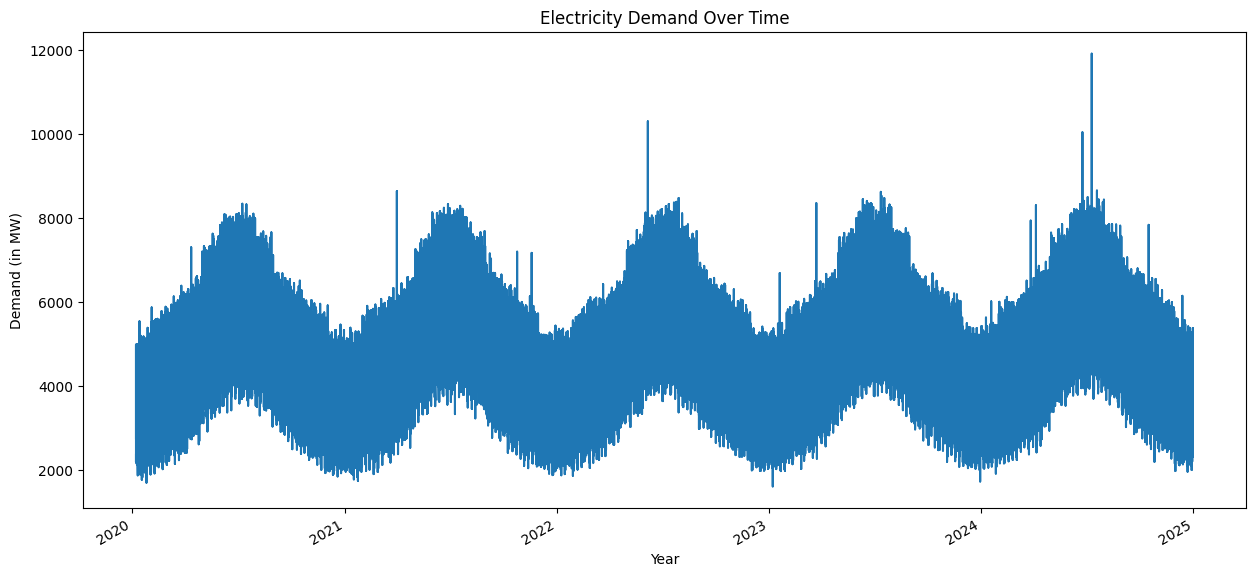

In [325]:
#Visualizations

#Plot raw demand over time

df['Demand'].plot(figsize=(15,7), title='Electricity Demand Over Time')
plt.xlabel('Year')
plt.ylabel('Demand (in MW)')
plt.show()

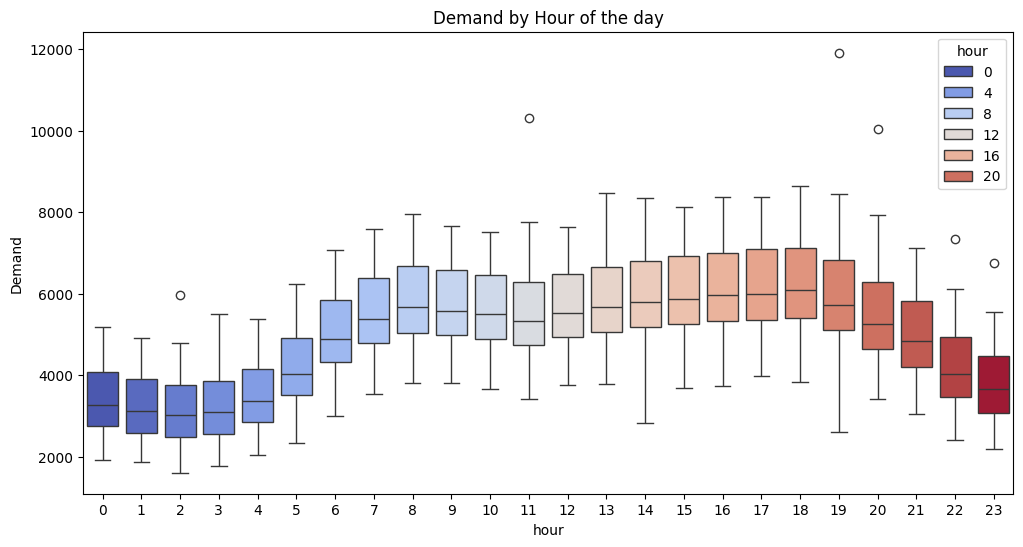

In [326]:
#visual Demand by hour of day

plt.figure(figsize=(12,6))
sns.boxplot(data = df, x = 'hour', y = "Demand", palette='coolwarm', hue='hour')
plt.title('Demand by Hour of the day')
plt.show()

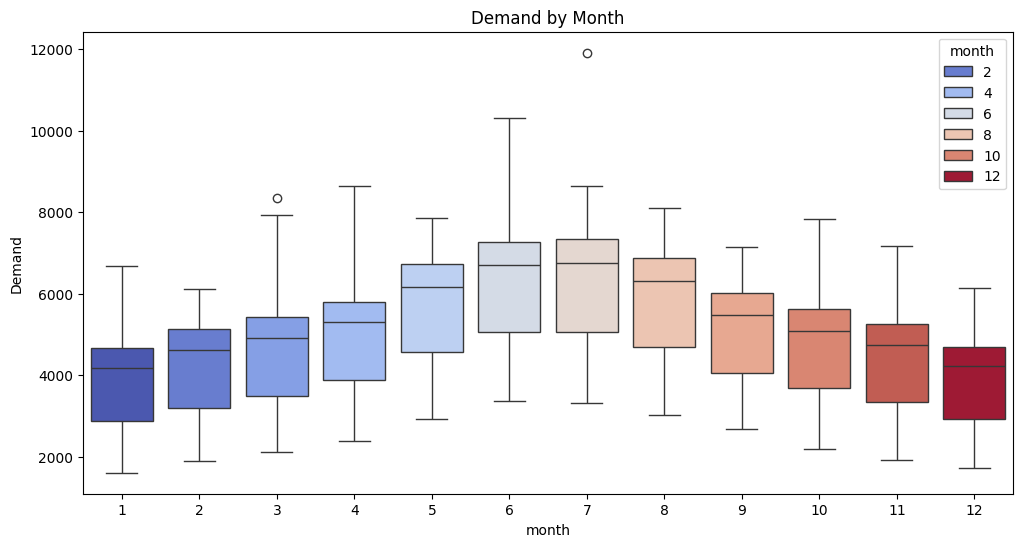

In [327]:
#Visual Demand by Month

plt.figure(figsize=(12,6))
sns.boxplot(data = df, x = 'month', y = "Demand", palette='coolwarm', hue='month')
plt.title('Demand by Month')
plt.show()

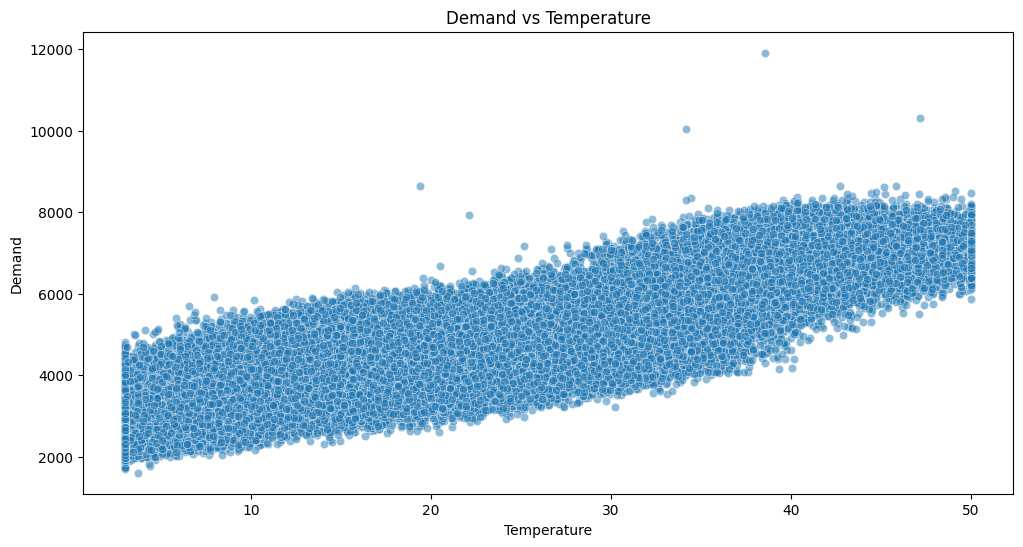

In [328]:
#Scatter plot for Demand vs Temrature

plt.figure(figsize=(12,6))
sns.scatterplot(data = df, x = 'Temperature', y = 'Demand', alpha = 0.5)
plt.title('Demand vs Temperature')
plt.show()

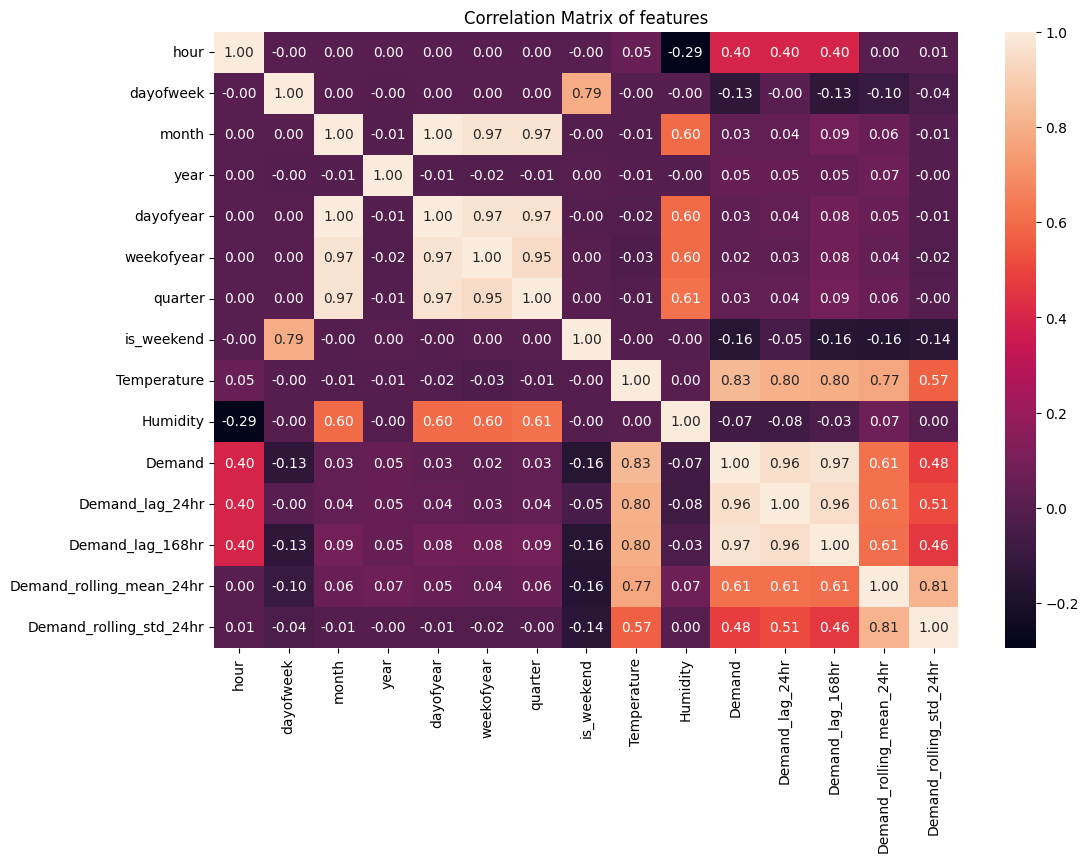

In [329]:
#Correlation Marix

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt = '0.2f')
plt.title('Correlation Matrix of features')
plt.show()

In [330]:
Y = df.Demand    #Dependent Value / Target Value

x = df.drop('Demand', axis = 1)    #Independent Values / Predictor Values

In [331]:
#Splitting data into training and testing data

x_train = x.loc[ : '2023-12-31']   #Taking 80% of data to training
Y_train = Y.loc[ : '2023-12-31'] 

x_test = x.loc['2024-01-01' : ]    #Taking 20% of data to Testing
Y_test = Y.loc['2024-01-01' : ]
Y_test

Timestamp
2024-01-01    2720.606072
2024-01-01    2669.647167
2024-01-01    2435.578924
2024-01-01    2641.043699
2024-01-01    2687.949643
                 ...     
2024-12-31    4689.693109
2024-12-31    4331.249224
2024-12-31    4015.979957
2024-12-31    3353.241682
2024-12-31    3219.023339
Name: Demand, Length: 8784, dtype: float64

In [332]:
print(x_train.shape)
print(Y_train.shape)

print(x_test.shape)
print(Y_test.shape)

(34892, 14)
(34892,)
(8784, 14)
(8784,)


# **XGBoost**

XGBoost is a powerful algorithm for time-series forecasting, as it can handle non-linear data easily.

It can handle seasonality and trends in time-series data effectively.

In [333]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error #To Evaluate Model Performance

from sklearn.model_selection import TimeSeriesSplit

In [334]:
# Initialize and training model


model_xgb = XGBRegressor(n_estimators = 1000,
                        early_stopping_rounds = 50,
                        learning_rate = 0.01,
                        random_state = 42, 
                        objective = 'reg:squarederror')

## In short:

The **XGBRegressor** initialization creates a model that will train for up to **1000 boosting rounds (trees)** but will stop early if performance on a validation set doesn't improve for **50 consecutive rounds**.

Each tree's contribution is scaled down by a **learning rate of 0.01** to prevent overfitting.

This model is designed to minimize the **squared error** for regression tasks.

In [335]:
model_xgb.fit(x_train, Y_train, eval_set =[(x_train, Y_train),(x_test, Y_test)], verbose = False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [336]:
# Make Predictions

predictons_xgb = model_xgb.predict(x_test)

In [337]:
# Evaluating the Model 

rmse_xgb = np.sqrt(mean_squared_error(Y_test, predictons_xgb))

mae_xgb = mean_absolute_error(Y_test, predictons_xgb)

In [338]:
print('XGBoost RMSE :',rmse_xgb)
print('XGBoost MAE :',mae_xgb)

XGBoost RMSE : 175.07965552482665
XGBoost MAE : 123.32653722857253


In [339]:
model_xgb.score(x_test, Y_test)

0.9846467164984454

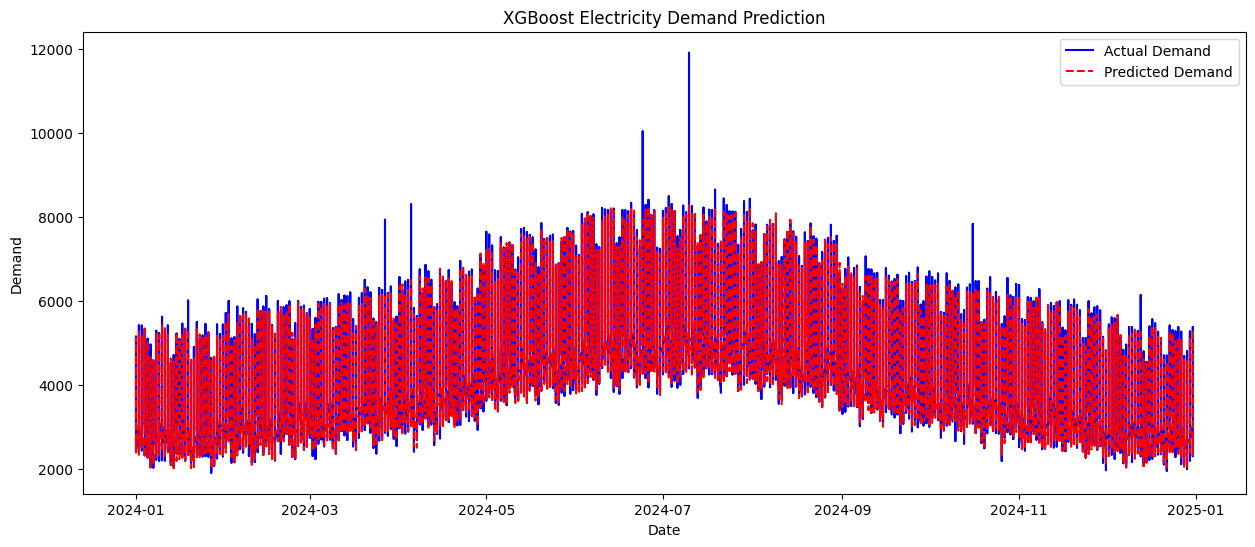

In [340]:
# Visualize the Predictions

plt.figure(figsize=(15,6))
plt.plot(Y_test.index, Y_test, label = 'Actual Demand' , color = 'Blue') #Actual Deamnd in Blue
plt.plot(Y_test.index, predictons_xgb, label = 'Predicted Demand' , color = 'Red', linestyle = '--') # Prdicted Demand in Red
plt.title('XGBoost Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()

In [341]:
#Save the model

import joblib

joblib.dump(model_xgb, 'Electricity_xgb_prediction_model.pkl')

['Electricity_xgb_prediction_model.pkl']

In [342]:
#load ande Use:

loaded_model = joblib.load('Electricity_xgb_prediction_model.pkl')

#future_predictions = loaded_model.predict(X_features)